# Income extension to the bakery count models

This notebook tests whether estimated household income provides additional explanatory value beyond population and transport accessibility.

In [1]:
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns


DATA_DATE = "2026-07-23"

SPATIAL_RAW_FOLDER = Path("../data/spatial/raw")
SPATIAL_RAW_FOLDER.mkdir(parents=True, exist_ok=True)

SPATIAL_PROCESSED_FOLDER = Path("../data/spatial/processed")

MODEL_OUTPUT_FOLDER = Path("../outputs/models")
MODEL_OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

TABLE_FOLDER = Path("../outputs/tables")
TABLE_FOLDER.mkdir(parents=True, exist_ok=True)

INCOME_PATH = (SPATIAL_RAW_FOLDER / "ons_msoa_income_fye2023.xlsx")
BASE_MODEL_PATH = (MODEL_OUTPUT_FOLDER / f"london_msoa_bakery_model_predictions_{DATA_DATE}.csv")
BASE_COMPARISON_PATH = (TABLE_FOLDER / f"bakery_count_model_comparison_{DATA_DATE}.csv")
BASE_PREDICTION_SUMMARY_PATH = (TABLE_FOLDER / f"negative_binomial_prediction_summary_{DATA_DATE}.csv")

FIGURE_FOLDER = Path("../outputs/figures")
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

In [2]:
income_column = ("Disposable (net) annual income before housing costs (£)")

income_data = pd.read_excel(INCOME_PATH,
                            sheet_name="Net income before housing costs",
                            header=3,
                            usecols=["MSOA code", income_column],
                            dtype={"MSOA code": "string"})

income_data = income_data.rename(columns={"MSOA code": "msoa_code",
                                          income_column: "income_bhc"})

income_data["msoa_code"] = (income_data["msoa_code"].str.strip())

income_data["income_bhc"] = pd.to_numeric(income_data["income_bhc"],
                                          errors="coerce")

print(f"Income rows: {len(income_data)}")
print(f"Duplicate MSOA codes: {income_data["msoa_code"].duplicated().sum()}")
print(f"Missing income estimates: {income_data["income_bhc"].isna().sum()}")

display(income_data.head())

Income rows: 7264
Duplicate MSOA codes: 0
Missing income estimates: 0


,msoa_code,income_bhc
0,E02002483,34333
1,E02002484,28027
2,E02002485,29585
3,E02002489,28352
4,E02002490,28832


## Merge income with the base modelling dataset

Income is joined to the saved Notebook 17 modelling output using MSOA code. That base model and income-extended model are fitted to the same 1,002 MSOAs.

In [3]:
base_model_data = pd.read_csv(BASE_MODEL_PATH, 
                              dtype={"msoa_code": "string"}, 
                              low_memory=False)

model_data = base_model_data.merge(income_data[["msoa_code", "income_bhc"]],
                                   on="msoa_code",
                                   how="left",
                                   validate="one_to_one")

missing_income = model_data["income_bhc"].isna().sum()

print(f"Base modelling rows: {len(base_model_data)}")
print(f"Rows after income merge: {len(model_data)}")
print(f"Missing income estimates: {missing_income}")
print(f"Duplicate MSOA codes: {model_data["msoa_code"].duplicated().sum()}")

model_data["income_bhc_10000"] = (model_data["income_bhc"] / 10000)

model_data["income_bhc_1000"] = (model_data["income_bhc"] / 1000)

display(model_data["income_bhc"]
        .describe().round(2))

Base modelling rows: 1002
Rows after income merge: 1002
Missing income estimates: 0
Duplicate MSOA codes: 0


count      1002.00
mean      47447.98
std        8729.29
min       31719.00
25%       41183.50
50%       45839.00
75%       52335.75
max      107582.00
Name: income_bhc, dtype: float64

## Explore income and bakery provision

Spearman correlations are used to examine the unadjusted relationships between estimated household income, all three bakery definitions and the existing model predictors.

Scatterplots are also used to show how bakery counts vary across MSOAs with different estimated income levels.

In [4]:
relationship_columns = {"Population": "population",
                        "Transport nodes": "transport_nodes",
                        "Core only": "core_bakery_count",
                        "Core and café": "core_and_cafe_count",
                        "All provision included": "bakery_count"}

income_correlation_rows = []

for relationship, column in relationship_columns.items():

    correlation = (model_data[["income_bhc", column]]
                   .corr(method="spearman")
                   .loc["income_bhc", column])

    income_correlation_rows.append({"Relationship": relationship,
                                    "Spearman correlation with income": correlation})

income_correlations = pd.DataFrame(income_correlation_rows)

display(income_correlations.round({"Spearman correlation with income": 3}))

,Relationship,Spearman correlation with income
0,Population,-0.254
1,Transport nodes,0.105
2,Core only,0.118
3,Core and café,0.285
4,All provision included,0.211


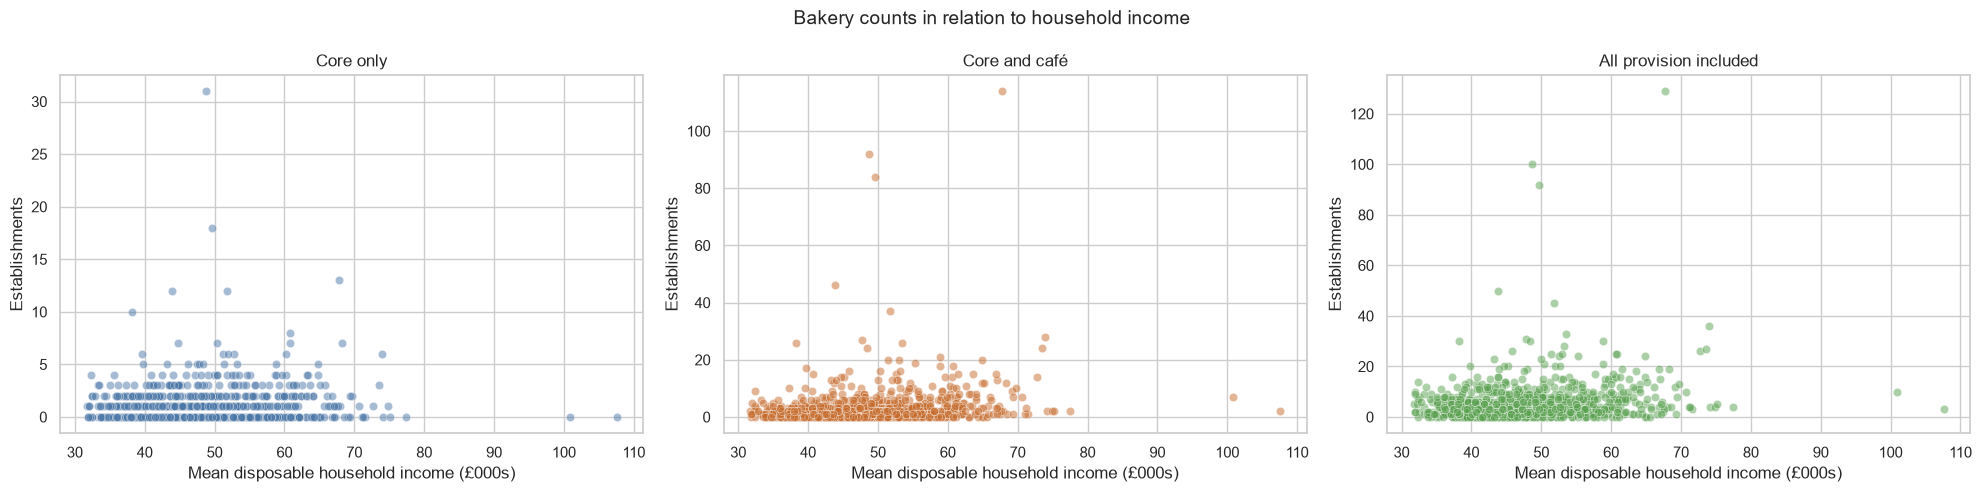

Saved to: ..\outputs\figures\bakery_counts_and_household_income.png


In [5]:
scatter_definitions = [("Core only","core_bakery_count", "#4c78a8"),
                       ("Core and café", "core_and_cafe_count", "#c66b2b"),
                       ("All provision included", "bakery_count", "#59a14f")]

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=True)

for axis, (definition, outcome, colour) in zip(axes, scatter_definitions):
    sns.scatterplot(data=model_data,
                    x="income_bhc_1000",
                    y=outcome,
                    color=colour,
                    alpha=0.5,
                    ax=axis)

    axis.set_title(definition)
    axis.set_xlabel("Mean disposable household income (£000s)")
    axis.set_ylabel("Establishments")

fig.suptitle("Bakery counts in relation to household income", fontsize=14)

plt.tight_layout()

INCOME_SCATTER_PATH = (FIGURE_FOLDER / "bakery_counts_and_household_income.png")
plt.savefig(INCOME_SCATTER_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {INCOME_SCATTER_PATH}")

Income had a weak positive relationship with all three bakery definitions with it being weakest for core bakeries and strongest when bakery cafés were included. Income had only a weak positive correlation with transport nodes, which could indicate that it represents a different characteristic rather than duplicating an existing accessibility predictor.

The extended models therefore test whether income remains associated with bakery provision after population and transport accessibility are controlled.

## Fit the income-extended models

The Negative Binomial models from Notebook 17 are extended by adding income measured in units of £10,000.

In [6]:
outcome_columns = {"Core only": "core_bakery_count",
                   "Core and café": "core_and_cafe_count",
                   "All provision included": "bakery_count"}

income_models = {}
income_model_rows = []

for definition, outcome in outcome_columns.items():
    formula = (f"{outcome} ~ population_1000 + log_transport_nodes + income_bhc_10000")

    model = smf.negativebinomial(formula=formula, data=model_data
                                 ).fit(disp=False, maxiter=200)

    income_models[definition] = model

    income_model_rows.append({"Definition": definition,
                              "Income model AIC": model.aic,
                              "Income model log-likelihood": model.llf,
                              "Income model alpha": model.params["alpha"]})

income_model_summary = pd.DataFrame(income_model_rows)

display(income_model_summary.round({"Income model AIC": 2,
                                    "Income model log-likelihood": 2,
                                    "Income model alpha": 3}))

,Definition,Income model AIC,Income model log-likelihood,Income model alpha
0,Core only,2548.87,-1269.44,1.080
1,Core and café,4127.12,-2058.56,1.088
2,All provision included,5205.47,-2597.74,0.662


## Compare base and income-extended models

Lower AIC indicates better model fit.

In [7]:
base_model_comparison = pd.read_csv(BASE_COMPARISON_PATH)

income_model_comparison = (base_model_comparison[["Definition", "Negative Binomial AIC"]]
                           .rename(columns={"Negative Binomial AIC": "Base model AIC"})
                           .merge(income_model_summary[["Definition",
                                                        "Income model AIC",
                                                        "Income model alpha"]],
                                                        on="Definition",
                                                        how="left",
                                                        validate="one_to_one"))

income_model_comparison["AIC improvement"
                        ] = (income_model_comparison["Base model AIC"] - income_model_comparison["Income model AIC"])

display(income_model_comparison.round({"Base model AIC": 2,
                                       "Income model AIC": 2,
                                       "Income model alpha": 3,
                                       "AIC improvement": 2}))

,Definition,Base model AIC,Income model AIC,Income model alpha,AIC improvement
0,Core only,2558.37,2548.87,1.080,9.50
1,Core and café,4208.66,4127.12,1.088,81.54
2,All provision included,5270.81,5205.47,0.662,65.34


## Interpret the extended model coefficients

Income is interpreted as the estimated change associated with an additional £10,000 of mean equivalised disposable annual household income, holding population and transport accessibility constant.

In [8]:
predictor_settings = {"population_1000": {"label": "Additional 1,000 residents",
                                          "change": 1},
                      "log_transport_nodes": {"label": "Approximate doubling of transport nodes",
                                              "change": np.log(2)},
                      "income_bhc_10000": {"label": "Additional £10,000 household income",
                                           "change": 1}}

coefficient_rows = []

for definition, model in income_models.items():
    confidence_intervals = model.conf_int()

    for predictor, settings in predictor_settings.items():
        change = settings["change"]

        incidence_rate_ratio = np.exp(model.params[predictor] * change)
        confidence_lower = np.exp(confidence_intervals.loc[predictor, 0] * change)
        confidence_upper = np.exp(confidence_intervals.loc[predictor, 1] * change)

        coefficient_rows.append({"Definition": definition,
                                 "Predictor": settings["label"],
                                 "Incidence rate ratio": incidence_rate_ratio,
                                 "Expected count change (%)": (incidence_rate_ratio - 1) * 100,
                                 "95% CI lower": confidence_lower,
                                 "95% CI upper": confidence_upper,
                                 "p-value": model.pvalues[predictor]})

income_coefficient_table = pd.DataFrame(coefficient_rows)

display(income_coefficient_table.round({"Incidence rate ratio": 3,
                                        "Expected count change (%)": 1,
                                        "95% CI lower": 3,
                                        "95% CI upper": 3,
                                        "p-value": 4}))

,Definition,Predictor,Incidence rate ratio,Expected count change (%),95% CI lower,95% CI upper,p-value
0,Core only,"Additional 1,000 residents",1.012,1.2,0.962,1.064,0.6393
1,Core only,Approximate doubling of transport nodes,1.754,75.4,1.554,1.981,0.0000
2,Core only,"Additional £10,000 household income",1.215,21.5,1.086,1.361,0.0007
3,Core and café,"Additional 1,000 residents",1.035,3.5,0.993,1.078,0.1010
4,Core and café,Approximate doubling of transport nodes,1.763,76.3,1.605,1.937,0.0000
5,Core and café,"Additional £10,000 household income",1.528,52.8,1.393,1.676,0.0000
6,All provision included,"Additional 1,000 residents",1.076,7.6,1.043,1.110,0.0000
7,All provision included,Approximate doubling of transport nodes,1.606,60.6,1.490,1.730,0.0000
8,All provision included,"Additional £10,000 household income",1.334,33.4,1.244,1.430,0.0000


## Compare predictions

In [9]:
income_prediction_rows = []

for definition, outcome in outcome_columns.items():
    model = income_models[definition]

    expected_column = f"income_expected_{outcome}"

    model_data[expected_column] = model.predict(model_data)

    observed = model_data[outcome]
    expected = model_data[expected_column]

    alpha = model.params["alpha"]

    zero_probabilities = (1 + alpha * expected) ** (-1 / alpha)

    income_prediction_rows.append({"Definition": definition,
                                   "Income expected mean": expected.mean(),
                                   "Income estimated zero MSOAs": (zero_probabilities.sum()),
                                   "Income mean absolute error": (observed - expected).abs().mean(),
                                   "Income expected maximum": expected.max()})

income_prediction_summary = pd.DataFrame(income_prediction_rows)

base_prediction_summary = pd.read_csv(BASE_PREDICTION_SUMMARY_PATH)

prediction_comparison = (
    base_prediction_summary[
        ["Definition",
         "Observed mean",
         "Expected mean",
         "Observed maximum",
         "Expected maximum",
         "Observed zero MSOAs",
         "Model-estimated zero MSOAs",
         "Mean absolute error"]]
         .rename(columns={"Expected mean": "Base expected mean",
                          "Expected maximum": "Base expected maximum",
                          "Model-estimated zero MSOAs": ("Base estimated zero MSOAs"),
                          "Mean absolute error": ("Base mean absolute error")})
                          .merge(income_prediction_summary,
                                  on="Definition",
                                  how="left",
                                  validate="one_to_one"))

display(prediction_comparison.round({"Observed mean": 2,
                                     "Base expected mean": 2,
                                     "Income expected mean": 2,
                                     "Base expected maximum": 2,
                                     "Income expected maximum": 2,
                                     "Base estimated zero MSOAs": 1,
                                     "Income estimated zero MSOAs": 1,
                                     "Base mean absolute error": 2,
                                     "Income mean absolute error": 2,
                                     "Income expected maximum": 2}))

,Definition,Observed mean,Base expected mean,Observed maximum,Base expected maximum,Observed zero MSOAs,Base estimated zero MSOAs,Base mean absolute error,Income expected mean,Income estimated zero MSOAs,Income mean absolute error,Income expected maximum
0,Core only,0.92,0.90,31,6.06,557,558.5,1.01,0.91,558.3,0.99,9.28
1,Core and café,2.92,2.77,114,20.79,304,332.1,2.72,2.80,327.7,2.52,49.24
2,All provision included,5.17,5.05,129,35.91,120,142.3,3.81,5.07,138.8,3.63,65.96


## Save income-model outputs

In [10]:
INCOME_MODEL_PATH = (MODEL_OUTPUT_FOLDER / f"london_msoa_bakery_income_model_predictions_{DATA_DATE}.csv")
INCOME_COMPARISON_PATH = (TABLE_FOLDER / f"income_model_comparison_{DATA_DATE}.csv")
INCOME_COEFFICIENT_PATH = (TABLE_FOLDER / f"income_model_coefficients_{DATA_DATE}.csv")
INCOME_PREDICTION_PATH = (TABLE_FOLDER / f"income_model_prediction_comparison_{DATA_DATE}.csv")
INCOME_CORRELATION_PATH = (TABLE_FOLDER / f"income_correlations_{DATA_DATE}.csv")

model_data.to_csv(INCOME_MODEL_PATH, index=False, encoding="utf-8-sig")
income_model_comparison.to_csv(INCOME_COMPARISON_PATH, index=False, encoding="utf-8-sig")
income_coefficient_table.to_csv(INCOME_COEFFICIENT_PATH, index=False, encoding="utf-8-sig")
prediction_comparison.to_csv(INCOME_PREDICTION_PATH, index=False, encoding="utf-8-sig")
income_correlations.to_csv(INCOME_CORRELATION_PATH, index=False, encoding="utf-8-sig")

print(f"Income model data saved to: {INCOME_MODEL_PATH}")
print(f"Model comparison saved to: {INCOME_COMPARISON_PATH}")
print(f"Coefficient table saved to: {INCOME_COEFFICIENT_PATH}")
print(f"Prediction comparison saved to: {INCOME_PREDICTION_PATH}")
print(f"Correlation table saved to: {INCOME_CORRELATION_PATH}")

Income model data saved to: ..\outputs\models\london_msoa_bakery_income_model_predictions_2026-07-23.csv
Model comparison saved to: ..\outputs\tables\income_model_comparison_2026-07-23.csv
Coefficient table saved to: ..\outputs\tables\income_model_coefficients_2026-07-23.csv
Prediction comparison saved to: ..\outputs\tables\income_model_prediction_comparison_2026-07-23.csv
Correlation table saved to: ..\outputs\tables\income_correlations_2026-07-23.csv
